# Analisis de sentimiento y Trading con FinMultiTime

## Autor: Eloi Serantes Abal

In [ ]:
!pip install sumy pyarrow pandas tqdm nltk

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 73.6 MB/s eta 0:00:00
  Created wheel for breadability: filename=breadability-0.1.20-py2.py3-none-any.whl size=21695 sha256=dd080b377b70823344a597a0f4a03fbc35a8270f0f34a7fbe360b352d1b9ff50
  Stored in directory: /root/.cache/pip/wheels/32/99/64/59305409cacd03aa03e7bddf31a9db34b1fa7033bd41972662
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=37ad75dda0e3c46a7f3c326320ab72853459b00a8dd20a85bbf76afff9f5f206
  Stored in directory: /root/.cache/pip/wheels/1a/bf/a1/4cee4f7678c68c5875ca89eaccf460593539805c3906722228
Successfully built breadability docopt


In [ ]:
!pip install transformers torch tqdm pandas pyarrow

- Librerías usadas.

In [ ]:
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import nltk
from tqdm import tqdm

from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.lex_rank import LexRankSummarizer
from sumy.nlp.stemmers import Stemmer
from sumy.utils import get_stop_words
from google.colab import drive

import pyarrow as pa
import zipfile
import gc
import time
from huggingface_hub import hf_hub_download
import requests
import io
import matplotlib.pyplot as plt
import warnings

import torch
from transformers import pipeline
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

print("Conectando con Google Drive...")
drive.mount('/content/drive')

# 3. Descargas necesarias del motor de NLTK
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# 4. Activar tqdm para ver barras de progreso en pandas
tqdm.pandas()

Conectando con Google Drive...
Mounted at /content/drive


## Análisis de sentimiento con FinMultiTime

Se analiza de el dataset FinMultiTime para ver si es un posible candidato para el uso de este sistema. Se comienza analizando cuantos datos cuentan con el ticker de la empresa, fecha y cuerpo del artículo.

In [ ]:
def convertir_finn_a_parquet_con_ticker_y_fecha():
    dataset_id = "Wenyan0110/Multimodal-Dataset-Image_Text_Table_TimeSeries-for-Financial-Time-Series-Forecasting"
    archivo_zip = "text/sp500_news.zip"

    RUTA_SALIDA = '/content/drive/MyDrive/GIA/TFG/FinnMultiTime_Articles_Ticker_Date.parquet'

    print("="*75)
    print("INICIANDO CONVERSIÓN DE BIG DATA A PARQUET (ARTÍCULO, TICKER Y FECHA)")
    print("="*75)

    tiempo_inicio = time.time()

    print("Conectando con Hugging Face y descargando ZIP...")
    path_local = hf_hub_download(repo_id=dataset_id, filename=archivo_zip, repo_type="dataset")

    writer = None
    total_articulos_guardados = 0

    print("Procesando JSONL secuencialmente y escribiendo en Parquet...")
    with zipfile.ZipFile(path_local, 'r') as z:
        archivos_jsonl = [n for n in z.namelist() if n.lower().endswith('.jsonl')]
        total_archivos = len(archivos_jsonl)

        for i, archivo in enumerate(archivos_jsonl):
            ticker_desde_archivo = archivo.split('/')[-1].replace('.jsonl', '').replace('.JSONL', '').upper()

            with z.open(archivo) as f:
                df_temp = pd.read_json(f, lines=True)
                if 'Article' in df_temp.columns and 'Date' in df_temp.columns:
                    if 'Stock_symbol' in df_temp.columns:
                        df_chunk = df_temp[['Article', 'Stock_symbol', 'Date']].copy()
                    else:
                        df_chunk = df_temp[['Article', 'Date']].copy()
                        df_chunk['Stock_symbol'] = ticker_desde_archivo

                    df_chunk = df_chunk.dropna(subset=['Article', 'Stock_symbol', 'Date'])
                    df_chunk['Article'] = df_chunk['Article'].astype(str)
                    df_chunk['Stock_symbol'] = df_chunk['Stock_symbol'].astype(str)
                    df_chunk['Date'] = df_chunk['Date'].astype(str)

                    df_chunk.reset_index(drop=True, inplace=True)

                    if not df_chunk.empty:
                        table = pa.Table.from_pandas(df_chunk, preserve_index=False)

                        if writer is None:
                            writer = pq.ParquetWriter(RUTA_SALIDA, table.schema, compression='snappy')

                        writer.write_table(table)
                        total_articulos_guardados += len(df_chunk)

                del df_temp
                if 'df_chunk' in locals():
                    del df_chunk
                gc.collect()

            if (i + 1) % 50 == 0 or (i + 1) == total_archivos:
                print(f"   [Progreso] Escritos {i + 1}/{total_archivos} archivos... ({total_articulos_guardados:,} artículos)")

    if writer:
        writer.close()

    tiempo_total = time.time() - tiempo_inicio
    print("\n" + "="*75)
    print(f"¡CONVERSIÓN COMPLETADA en {int(tiempo_total // 60)}m {int(tiempo_total % 60)}s!")
    print(f"Se ha guardado un Parquet con {total_articulos_guardados:,} artículos en: {RUTA_SALIDA}")
    print("="*75)

In [ ]:
convertir_finn_a_parquet_con_ticker_y_fecha()

INICIANDO CONVERSIÓN DE BIG DATA A PARQUET (ARTÍCULO, TICKER Y FECHA)
-> 1. Conectando con Hugging Face y descargando ZIP...
-> 2. Procesando JSONL secuencialmente y escribiendo en Parquet...
   [Progreso] Escritos 50/4694 archivos... (66,555 artículos)
   [Progreso] Escritos 100/4694 archivos... (104,995 artículos)
   [Progreso] Escritos 150/4694 archivos... (141,595 artículos)
   [Progreso] Escritos 200/4694 archivos... (193,702 artículos)
   [Progreso] Escritos 250/4694 archivos... (240,499 artículos)
   [Progreso] Escritos 300/4694 archivos... (279,894 artículos)
   [Progreso] Escritos 350/4694 archivos... (319,506 artículos)
   [Progreso] Escritos 400/4694 archivos... (337,874 artículos)
   [Progreso] Escritos 450/4694 archivos... (371,004 artículos)
   [Progreso] Escritos 500/4694 archivos... (404,417 artículos)
   [Progreso] Escritos 550/4694 archivos... (455,641 artículos)
   [Progreso] Escritos 600/4694 archivos... (486,663 artículos)
   [Progreso] Escritos 650/4694 archivos..

In [ ]:
RUTA_ENTRADA = '/content/drive/MyDrive/GIA/TFG/FinnMultiTime_Articles_Ticker_Date.parquet'

print("Conectando al archivo Parquet en modo streaming...")
archivo_parquet = pq.ParquetFile(RUTA_ENTRADA)
total_filas = archivo_parquet.metadata.num_rows
columnas = archivo_parquet.schema.names

print(f"\nINFORMACIÓN BÁSICA:")
print(f"Total de noticias a procesar: {total_filas:,}")
print(f"Columnas disponibles: {columnas}")
print("\nCalculando noticias válidas (filtrando nulos y textos cortos)...")
total_validas = 0

for batch in archivo_parquet.iter_batches(batch_size=10000):
    df_chunk = batch.to_pandas()

    if 'Article' in df_chunk.columns:
        chunk_limpio = df_chunk.dropna(subset=['Article'])
        chunk_limpio = chunk_limpio[chunk_limpio['Article'].astype(str).str.strip().str.len() > 50]
        total_validas += len(chunk_limpio)

    del df_chunk

print(f"Total de noticias válidas tras limpieza: {total_validas:,}")
print(f"Noticias descartadas (ruido/vacías): {total_filas - total_validas:,}")

Conectando al archivo Parquet en modo streaming...

INFORMACIÓN BÁSICA:
Total de noticias a procesar: 3,049,479
Columnas disponibles: ['Article', 'Stock_symbol', 'Date']

Calculando noticias válidas (filtrando nulos y textos cortos)...
Total de noticias válidas tras limpieza: 3,049,449
Noticias descartadas (ruido/vacías): 30


Al ver que se cuentan con muchos datos, se decide filtrarlos para ver si pertenecen al S&P 500.

In [ ]:
RUTA_SALIDA = '/content/drive/MyDrive/GIA/TFG/FinnMultiTime_Filtered_SP500.parquet'

START_DATE = pd.to_datetime("2010-01-01", utc=True)
END_DATE = pd.to_datetime("2024-01-01", utc=True)
TAMAÑO_LOTE = 50000

print("="*75)
print("INICIANDO FILTRADO DEL DATASET (S&P 500 | 2010 - 2024)")
print("="*75)

# OBTENER TICKERS DEL S&P 500
print("-> Obteniendo la lista oficial de tickers del S&P 500 desde Wikipedia...")
url_sp500 = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}
respuesta = requests.get(url_sp500, headers=headers)
tabla_sp500 = pd.read_html(respuesta.text)[0]

tickers_sp500 = tabla_sp500['Symbol'].str.replace('.', '-').tolist()
print(f"Se han cargado {len(tickers_sp500)} tickers del S&P 500.")

tiempo_inicio = time.time()
archivo_parquet = pq.ParquetFile(RUTA_ENTRADA)
writer = None
total_analizados = 0
total_guardados = 0

print(f"\n-> Filtrando un total de {archivo_parquet.metadata.num_rows:,} noticias originales...")

for i, batch in enumerate(archivo_parquet.iter_batches(batch_size=TAMAÑO_LOTE)):
    df_chunk = batch.to_pandas()
    total_analizados += len(df_chunk)

    if 'Date' in df_chunk.columns and 'Stock_symbol' in df_chunk.columns:

        # Convertir la columna de fechas a datetime (forzando UTC para evitar conflictos de zona horaria)
        df_chunk['Date_Parsed'] = pd.to_datetime(df_chunk['Date'], errors='coerce', utc=True)

        # Limpiar nulos (por si alguna fecha no se pudo procesar)
        df_chunk = df_chunk.dropna(subset=['Date_Parsed', 'Stock_symbol'])

        # APLICAR MÁSCARAS DE FILTRADO
        mascara_fecha = (df_chunk['Date_Parsed'] >= START_DATE) & (df_chunk['Date_Parsed'] < END_DATE)
        mascara_ticker = df_chunk['Stock_symbol'].isin(tickers_sp500)

        # Filtramos el dataframe
        df_filtrado = df_chunk[mascara_fecha & mascara_ticker].copy()

        # Eliminamos la columna temporal de fechas y reseteamos índice
        df_filtrado = df_filtrado.drop(columns=['Date_Parsed']).reset_index(drop=True)

        # GUARDAR SI HAY DATOS VÁLIDOS
        if not df_filtrado.empty:
            table = pa.Table.from_pandas(df_filtrado, preserve_index=False)

            if writer is None:
                writer = pq.ParquetWriter(RUTA_SALIDA, table.schema, compression='snappy')

            writer.write_table(table)
            total_guardados += len(df_filtrado)

    # LIMPIEZA DE RAM
    del df_chunk
    if 'df_filtrado' in locals():
        del df_filtrado
    del batch
    if 'table' in locals():
        del table
    gc.collect()

    # Print de progreso (cada 2 lotes para no saturar la consola)
    if (i + 1) % 2 == 0:
        print(f"   [Progreso] Analizadas {total_analizados:,} | Retenidas {total_guardados:,} noticias...")

if writer:
    writer.close()

tiempo_total = time.time() - tiempo_inicio
print("\n" + "="*75)
print(f"¡FILTRADO COMPLETADO en {int(tiempo_total // 60)}m {int(tiempo_total % 60)}s!")
print(f"   -> Noticias Originales: {total_analizados:,}")
print(f"   -> Noticias Filtradas (S&P 500 + Rango): {total_guardados:,}")
print(f"   -> Reducción del dataset: {100 - (total_guardados/total_analizados)*100:.2f}%")
print(f"Archivo guardado en: {RUTA_SALIDA}")
print("="*75)

INICIANDO FILTRADO DEL DATASET (S&P 500 | 2010 - 2024)
-> Obteniendo la lista oficial de tickers del S&P 500 desde Wikipedia...


/tmp/ipykernel_19170/1209474508.py:24: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tabla_sp500 = pd.read_html(respuesta.text)[0]


Se han cargado 503 tickers del S&P 500.

-> Filtrando un total de 3,049,479 noticias originales...
   [Progreso] Analizadas 100,000 | Retenidas 35,213 noticias...
   [Progreso] Analizadas 200,000 | Retenidas 51,923 noticias...
   [Progreso] Analizadas 300,000 | Retenidas 89,113 noticias...
   [Progreso] Analizadas 400,000 | Retenidas 102,599 noticias...
   [Progreso] Analizadas 500,000 | Retenidas 116,529 noticias...
   [Progreso] Analizadas 600,000 | Retenidas 128,482 noticias...
   [Progreso] Analizadas 700,000 | Retenidas 152,219 noticias...
   [Progreso] Analizadas 800,000 | Retenidas 194,929 noticias...
   [Progreso] Analizadas 900,000 | Retenidas 224,813 noticias...
   [Progreso] Analizadas 1,000,000 | Retenidas 255,318 noticias...
   [Progreso] Analizadas 1,100,000 | Retenidas 281,165 noticias...
   [Progreso] Analizadas 1,200,000 | Retenidas 301,490 noticias...
   [Progreso] Analizadas 1,300,000 | Retenidas 309,647 noticias...
   [Progreso] Analizadas 1,400,000 | Retenidas 321,

Al disponer de un número de datos similar que en FNSPID, se decanta como un dataset interesante para probar el sistema. Lo malo de este dataset es que no dispone de las noticias resumidas. Para solucionarlo, se decide resumir las noticias empleando el mecanismo que se observa en el Apéndice 3 del paper de FNSPID.

## Proceso de resumen de FinMultiTime



In [ ]:
idioma = "english"
stemmer = Stemmer(idioma)
lexrank_base = LexRankSummarizer(stemmer)
lexrank_base.stop_words = get_stop_words(idioma)

def fnspid_custom_summarizer(texto, ticker, num_frases=3):
    """
    Replica la lógica del Anexo A.3 del paper FNSPID.
    """
    try:
        if not isinstance(texto, str) or pd.isna(texto): return ""
        ticker_str = str(ticker).lower() if isinstance(ticker, str) and pd.notna(ticker) else ""

        parser = PlaintextParser.from_string(texto, Tokenizer(idioma))
        documento = parser.document
        todas_las_frases = documento.sentences

        if len(todas_las_frases) <= num_frases:
            return texto

        frases_base = lexrank_base(documento, num_frases * 2)
        textos_base = [str(f) for f in frases_base]

        puntuaciones = []

        for i, frase_obj in enumerate(todas_las_frases):
            frase_str = str(frase_obj)
            frase_lower = frase_str.lower()

            # W_s: ¿Menciona el ticker? (Ecuación 4)
            w_s = 1 if (ticker_str and ticker_str in frase_lower) else 0
            # W_t: ¿Fue seleccionada por LexRank? (Ecuación 5)
            w_t = 1 if frase_str in textos_base else 0
            # W_f: Puntuación final (Ecuación 6)
            w_f = w_s + w_t

            puntuaciones.append({'frase': frase_str, 'w_f': w_f, 'orden_original': i})

        puntuaciones_ordenadas = sorted(puntuaciones, key=lambda x: (-x['w_f'], x['orden_original']))
        mejores_frases = puntuaciones_ordenadas[:num_frases]
        resumen_cronologico = sorted(mejores_frases, key=lambda x: x['orden_original'])

        return " ".join([item['frase'] for item in resumen_cronologico])

    except Exception:
        return str(texto)[:500]

In [ ]:
RUTA_ENTRADA = '/content/drive/MyDrive/GIA/TFG/FinnMultiTime_Filtered_SP500.parquet'
RUTA_SALIDA = '/content/drive/MyDrive/GIA/TFG/FinnMultiTime_Summarized_SP500_FNSPID.parquet'

COLUMNA_TEXTO = 'Article'
COLUMNA_TICKER = 'Stock_symbol'
TAMAÑO_LOTE = 5000

print("="*75)
print("INICIANDO GENERACIÓN DE RESÚMENES (S&P 500 | FNSPID LOGIC)")
print("="*75)

tiempo_inicio = time.time()
archivo_parquet = pq.ParquetFile(RUTA_ENTRADA)
writer = None
total_procesados = 0

print(f"Total de noticias estimadas en el archivo: {archivo_parquet.metadata.num_rows:,}")

for i, batch in enumerate(archivo_parquet.iter_batches(batch_size=TAMAÑO_LOTE)):
    df_chunk = batch.to_pandas()

    if COLUMNA_TEXTO in df_chunk.columns and COLUMNA_TICKER in df_chunk.columns:
        df_chunk = df_chunk.dropna(subset=[COLUMNA_TEXTO, COLUMNA_TICKER])
        df_chunk = df_chunk[df_chunk[COLUMNA_TEXTO].astype(str).str.strip().str.len() > 50].reset_index(drop=True)

        if not df_chunk.empty:
            df_chunk['FNSPID_Summary'] = df_chunk.apply(
                lambda fila: fnspid_custom_summarizer(fila[COLUMNA_TEXTO], fila[COLUMNA_TICKER]),
                axis=1
            )

            table = pa.Table.from_pandas(df_chunk, preserve_index=False)

            if writer is None:
                writer = pq.ParquetWriter(RUTA_SALIDA, table.schema, compression='snappy')

            writer.write_table(table)
            total_procesados += len(df_chunk)

    del df_chunk
    del batch
    if 'table' in locals():
        del table
    gc.collect()

    print(f"  [Progreso] Lote {i + 1} completado. Total acumulado guardado: {total_procesados:,} noticias.")

if writer:
    writer.close()

tiempo_total = time.time() - tiempo_inicio
print("\n" + "="*75)
print(f"RESÚMENES COMPLETADOS Y GUARDADOS en {int(tiempo_total // 60)}m {int(tiempo_total % 60)}s!")
print(f"Ruta: {RUTA_SALIDA}")
print("="*75)

INICIANDO GENERACIÓN DE RESÚMENES (S&P 500 | FNSPID LOGIC)
Total de noticias estimadas en el archivo: 718,050
  [Progreso] Lote 1 completado. Total acumulado guardado: 5,000 noticias.
  [Progreso] Lote 2 completado. Total acumulado guardado: 10,000 noticias.
  [Progreso] Lote 3 completado. Total acumulado guardado: 15,000 noticias.
  [Progreso] Lote 4 completado. Total acumulado guardado: 20,000 noticias.
  [Progreso] Lote 5 completado. Total acumulado guardado: 25,000 noticias.
  [Progreso] Lote 6 completado. Total acumulado guardado: 30,000 noticias.
  [Progreso] Lote 7 completado. Total acumulado guardado: 34,999 noticias.
  [Progreso] Lote 8 completado. Total acumulado guardado: 39,999 noticias.
  [Progreso] Lote 9 completado. Total acumulado guardado: 44,999 noticias.
  [Progreso] Lote 10 completado. Total acumulado guardado: 49,999 noticias.
  [Progreso] Lote 11 completado. Total acumulado guardado: 54,999 noticias.
  [Progreso] Lote 12 completado. Total acumulado guardado: 59,99

Al romperse la ejecucción debido a que se agotó el uso de la RAM, se comenzó desde el último lote que se guardo.

In [ ]:
RUTA_ENTRADA = '/content/drive/MyDrive/GIA/TFG/FinnMultiTime_Filtered_SP500.parquet'

RUTA_SALIDA_PARTE2 = '/content/drive/MyDrive/GIA/TFG/FinnMultiTime_Summarized_SP500_FNSPID_Parte2.parquet'

COLUMNA_TEXTO = 'Article'
COLUMNA_TICKER = 'Stock_symbol'
TAMAÑO_LOTE = 5000
LOTES_YA_COMPLETADOS = 77

print("="*75)
print(f"REANUDANDO RESÚMENES DESDE EL LOTE {LOTES_YA_COMPLETADOS + 1}")
print("="*75)

tiempo_inicio = time.time()
archivo_parquet = pq.ParquetFile(RUTA_ENTRADA)
writer = None
total_procesados_parte2 = 0

print(f"Total de noticias originales en el archivo: {archivo_parquet.metadata.num_rows:,}")

for i, batch in enumerate(archivo_parquet.iter_batches(batch_size=TAMAÑO_LOTE)):
    numero_lote_actual = i + 1

    if numero_lote_actual <= LOTES_YA_COMPLETADOS:
        if numero_lote_actual % 10 == 0 or numero_lote_actual == LOTES_YA_COMPLETADOS:
            print(f"Saltando lote {numero_lote_actual} (Ya procesado anteriormente)...")
        continue

    df_chunk = batch.to_pandas()

    if COLUMNA_TEXTO in df_chunk.columns and COLUMNA_TICKER in df_chunk.columns:
        df_chunk = df_chunk.dropna(subset=[COLUMNA_TEXTO, COLUMNA_TICKER])
        df_chunk = df_chunk[df_chunk[COLUMNA_TEXTO].astype(str).str.strip().str.len() > 50].reset_index(drop=True)

        if not df_chunk.empty:
            df_chunk['FNSPID_Summary'] = df_chunk.apply(
                lambda fila: fnspid_custom_summarizer(fila[COLUMNA_TEXTO], fila[COLUMNA_TICKER]),
                axis=1
            )

            table = pa.Table.from_pandas(df_chunk, preserve_index=False)

            if writer is None:
                writer = pq.ParquetWriter(RUTA_SALIDA_PARTE2, table.schema, compression='snappy')

            writer.write_table(table)
            total_procesados_parte2 += len(df_chunk)

    del df_chunk
    del batch
    if 'table' in locals():
        del table
    gc.collect()

    print(f"  [Progreso] Lote {numero_lote_actual} completado. Guardados en Parte 2: {total_procesados_parte2:,} noticias.")

if writer:
    writer.close()

tiempo_total = time.time() - tiempo_inicio
print("\n" + "="*75)
print(f"PARTE 2 COMPLETADA en {int(tiempo_total // 60)}m {int(tiempo_total % 60)}s!")
print(f"Ruta: {RUTA_SALIDA_PARTE2}")
print("="*75)

REANUDANDO RESÚMENES DESDE EL LOTE 78
Total de noticias originales en el archivo: 718,050
Saltando lote 10 (Ya procesado anteriormente)...
Saltando lote 20 (Ya procesado anteriormente)...
Saltando lote 30 (Ya procesado anteriormente)...
Saltando lote 40 (Ya procesado anteriormente)...
Saltando lote 50 (Ya procesado anteriormente)...
Saltando lote 60 (Ya procesado anteriormente)...
Saltando lote 70 (Ya procesado anteriormente)...
Saltando lote 77 (Ya procesado anteriormente)...
  [Progreso] Lote 78 completado. Guardados en Parte 2: 5,000 noticias.
  [Progreso] Lote 79 completado. Guardados en Parte 2: 10,000 noticias.
  [Progreso] Lote 80 completado. Guardados en Parte 2: 15,000 noticias.
  [Progreso] Lote 81 completado. Guardados en Parte 2: 20,000 noticias.
  [Progreso] Lote 82 completado. Guardados en Parte 2: 25,000 noticias.
  [Progreso] Lote 83 completado. Guardados en Parte 2: 30,000 noticias.
  [Progreso] Lote 84 completado. Guardados en Parte 2: 35,000 noticias.
  [Progreso] Lo

Al intentar fusionar las dos partes, se corrompió la primera. Por lo tanto, se optó por comenzar de nuevo desde el principio hasta el lote 77 de la primera parte.

In [ ]:
# --- CONFIGURACIÓN ---
RUTA_ENTRADA = '/content/drive/MyDrive/GIA/TFG/FinnMultiTime_Filtered_SP500.parquet'
RUTA_SALIDA_PARTE1_NUEVA = '/content/drive/MyDrive/GIA/TFG/FinnMultiTime_Summarized_Parte1_REPARADA.parquet'

LOTE_LIMITE = 77  # Frenamos aquí para que coincida con tu Parte 2
TAMAÑO_LOTE = 5000

print("="*75)
print(f"RECONSTRUYENDO PARTE 1 (Lotes 1 al {LOTE_LIMITE})")
print("="*75)

tiempo_inicio = time.time()
archivo_parquet = pq.ParquetFile(RUTA_ENTRADA)
writer = None
total_procesados = 0

for i, batch in enumerate(archivo_parquet.iter_batches(batch_size=TAMAÑO_LOTE)):
    num_lote = i + 1

    if num_lote > LOTE_LIMITE:
        print(f"\n Lote {LOTE_LIMITE} alcanzado. Cerrando archivo...")
        break

    df_chunk = batch.to_pandas()
    df_chunk = df_chunk.dropna(subset=['Article', 'Stock_symbol'])
    df_chunk['FNSPID_Summary'] = df_chunk.apply(lambda f: fnspid_custom_summarizer(f['Article'], f['Stock_symbol']), axis=1)

    table = pa.Table.from_pandas(df_chunk, preserve_index=False)
    if writer is None:
        writer = pq.ParquetWriter(RUTA_SALIDA_PARTE1_NUEVA, table.schema, compression='snappy')

    writer.write_table(table)
    total_procesados += len(df_chunk)

    print(f"  [Progreso] Lote {num_lote}/{LOTE_LIMITE} completado ({total_procesados:,} noticias)")
    del df_chunk, batch, table
    gc.collect()

if writer:
    writer.close()

print(f"\nParte 1 reparada con éxito! Guardada en: {RUTA_SALIDA_PARTE1_NUEVA}")

RECONSTRUYENDO PARTE 1 (Lotes 1 al 77)
  [Progreso] Lote 1/77 completado (5,000 noticias)
  [Progreso] Lote 2/77 completado (10,000 noticias)
  [Progreso] Lote 3/77 completado (15,000 noticias)
  [Progreso] Lote 4/77 completado (20,000 noticias)
  [Progreso] Lote 5/77 completado (25,000 noticias)
  [Progreso] Lote 6/77 completado (30,000 noticias)
  [Progreso] Lote 7/77 completado (35,000 noticias)
  [Progreso] Lote 8/77 completado (40,000 noticias)
  [Progreso] Lote 9/77 completado (45,000 noticias)
  [Progreso] Lote 10/77 completado (50,000 noticias)
  [Progreso] Lote 11/77 completado (55,000 noticias)
  [Progreso] Lote 12/77 completado (60,000 noticias)
  [Progreso] Lote 13/77 completado (65,000 noticias)
  [Progreso] Lote 14/77 completado (70,000 noticias)
  [Progreso] Lote 15/77 completado (75,000 noticias)
  [Progreso] Lote 16/77 completado (80,000 noticias)
  [Progreso] Lote 17/77 completado (85,000 noticias)
  [Progreso] Lote 18/77 completado (90,000 noticias)
  [Progreso] Lote

Juntamos ambas partes

In [ ]:
RUTA_PARTE1 = '/content/drive/MyDrive/GIA/TFG/FinnMultiTime_Summarized_Parte1_REPARADA.parquet'
RUTA_PARTE2 = '/content/drive/MyDrive/GIA/TFG/FinnMultiTime_Summarized_SP500_FNSPID_Parte2.parquet'
RUTA_FINAL = '/content/drive/MyDrive/GIA/TFG/FinnMultiTime_Summarized_SP500_FINAL.parquet'

print("Iniciando la unión de las dos partes...")

# CARGA DE TABLAS
try:
    tabla1 = pq.read_table(RUTA_PARTE1)
    print(f"Parte 1 cargada: {tabla1.num_rows:,} noticias.")

    tabla2 = pq.read_table(RUTA_PARTE2)
    print(f"Parte 2 cargada: {tabla2.num_rows:,} noticias.")

    # UNIÓN
    tabla_completa = pa.concat_tables([tabla1, tabla2])
    print(f"Total combinado: {tabla_completa.num_rows:,} noticias.")

    # GUARDADO
    pq.write_table(tabla_completa, RUTA_FINAL, compression='snappy')

    print("\n" + "="*50)
    print(f"¡ÉXITO! Dataset consolidado.")
    print(f"Ubicación: {RUTA_FINAL}")
    print("="*50)

except Exception as e:
    print(f"Error durante la unión: {e}")
    print("Asegúrate de que ambas rutas son correctas y los archivos no están corruptos.")

Iniciando la unión de las dos partes...
Parte 1 cargada: 385,000 noticias.
Parte 2 cargada: 333,050 noticias.
Total combinado: 718,050 noticias.

¡ÉXITO! Dataset consolidado.
Ubicación: /content/drive/MyDrive/GIA/TFG/FinnMultiTime_Summarized_SP500_FINAL.parquet


## Se observa la distribucción temporal de este nuevo dataset

ANÁLISIS TEMPORAL DEL DATASET DEFINITIVO (S&P 500)
1. Cargando el dataset en memoria...
2. Procesando fechas y calculando distribución...

ESTADÍSTICAS DEL DATASET
Total de noticias: 718,050
Ventana Temporal: Desde 2010-01-04 hasta 2023-12-16

3. Generando gráfico de distribución anual...


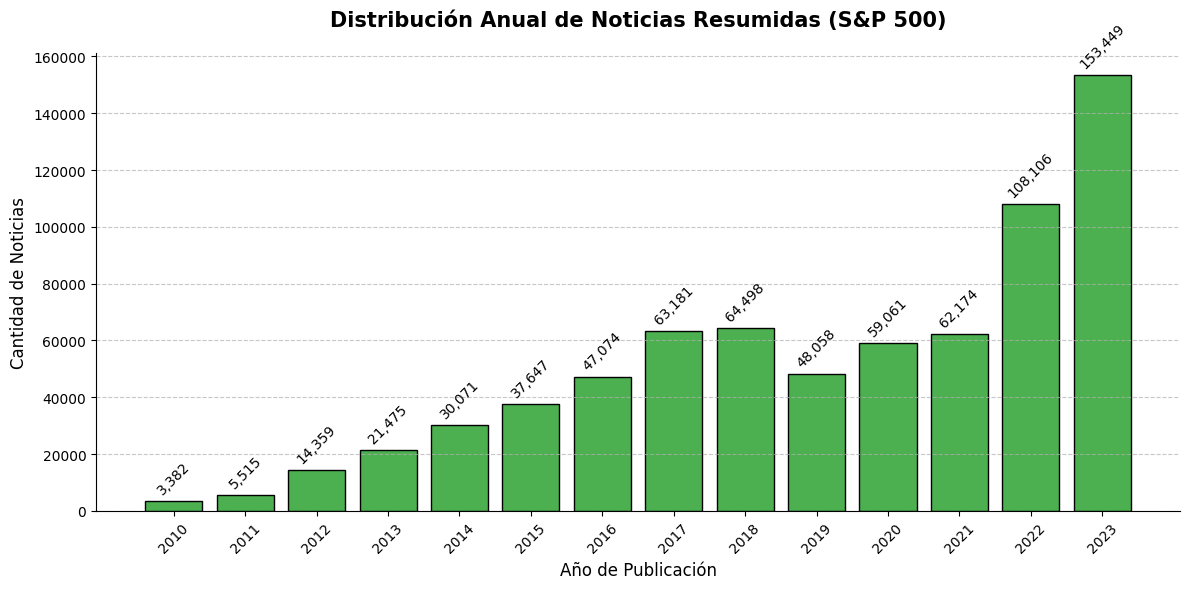

In [ ]:
RUTA_FINAL = '/content/drive/MyDrive/GIA/TFG/FinnMultiTime_Summarized_SP500_FINAL.parquet'

print("="*75)
print("ANÁLISIS TEMPORAL DEL DATASET DEFINITIVO (S&P 500)")
print("="*75)

print("Cargando el dataset en memoria...")
df_final = pd.read_parquet(RUTA_FINAL)

print("Procesando fechas y calculando distribución...")
df_final['Date'] = pd.to_datetime(df_final['Date'], errors='coerce', utc=True)
df_final = df_final.dropna(subset=['Date'])

df_final['Year'] = df_final['Date'].dt.year.astype(int)

fecha_min = df_final['Date'].min()
fecha_max = df_final['Date'].max()

print("\n" + "="*75)
print("ESTADÍSTICAS DEL DATASET")
print("="*75)
print(f"Total de noticias: {len(df_final):,}")
print(f"Ventana Temporal: Desde {fecha_min.strftime('%Y-%m-%d')} hasta {fecha_max.strftime('%Y-%m-%d')}")
print("="*75)

print("\nGenerando gráfico de distribución anual...")
conteo_por_ano = df_final['Year'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
barras = plt.bar(conteo_por_ano.index.astype(str), conteo_por_ano.values, color='#4CAF50', edgecolor='black')

for barra in barras:
    altura = barra.get_height()
    if altura > 0:
        plt.text(barra.get_x() + barra.get_width()/2., altura + (max(conteo_por_ano.values)*0.01),
                 f'{int(altura):,}', ha='center', va='bottom', fontsize=10, rotation=45)

plt.title('Distribución Anual de Noticias Resumidas (S&P 500)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Año de Publicación', fontsize=12)
plt.ylabel('Cantidad de Noticias', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

df_final = df_final.drop(columns=['Year'])

## Inferencia con FinBERT

In [ ]:
def finnmultitime_finbert_resumenes():
    print("="*60)
    print("FASE 2: INFERENCIA DE SENTIMIENTO FINBERT (S&P 500)")
    print("="*60)

    # Comprobación hardware
    device = 0 if torch.cuda.is_available() else -1
    if device == 0:
        print("GPU Detectada: El modelo correrá a máxima velocidad.")
    else:
        print("ADVERTENCIA: No se detectó GPU. El proceso correrá en CPU y será EXTREMADAMENTE lento.")
        print("   -> Te recomendamos detener la ejecución y activar la GPU en 'Entorno de ejecución'.\n")

    tiempo_inicio = time.time()

    ruta_entrada = '/content/drive/MyDrive/GIA/TFG/FinnMultiTime_Summarized_SP500_FINAL.parquet'
    ruta_salida_final = '/content/drive/MyDrive/GIA/TFG/FinnMultiTime_FinBERT_Sentiments.parquet'

    try:
        # Carga de datos
        print("1. Cargando dataset definitivo...")
        df = pd.read_parquet(ruta_entrada)

        # Verificamos que la columna del resumen existe
        columna_texto = 'FNSPID_Summary'
        if columna_texto not in df.columns:
            raise KeyError(f"La columna '{columna_texto}' no existe en el dataset. Columnas: {list(df.columns)}")

        # Configuración Modelo FinBERT
        print("\nDescargando/Cargando modelo ProsusAI/finbert en memoria...")
        # Usamos batch_size=64 o 128 para aprovechar la VRAM de la GPU
        analizador = pipeline("sentiment-analysis", model="ProsusAI/finbert", device=device, batch_size=128)

        resumenes = df[columna_texto].astype(str).tolist()

        print(f"\nProcesando sentimiento de {len(resumenes):,} resúmenes...")
        resultados = []

        for salida in tqdm(analizador(resumenes, truncation=True, max_length=512), total=len(resumenes), desc="Analizando"):
            resultados.append((salida['label'], salida['score']))

        print("\nInyectando resultados y guardando el archivo maestro...")
        df['Sentiment_Label'] = [res[0] for res in resultados]  # positive, negative, neutral
        df['Sentiment_Score'] = [res[1] for res in resultados]  # Nivel de confianza (0.0 a 1.0)

        df.to_parquet(ruta_salida_final, index=False)

        if device == 0:
            torch.cuda.empty_cache()

        tiempo_fin = time.time()
        segundos_totales = tiempo_fin - tiempo_inicio

        horas = int(segundos_totales // 3600)
        minutos = int((segundos_totales % 3600) // 60)
        segundos = int(segundos_totales % 60)

        print("\n" + "="*60)
        print(f"INFERENCIA COMPLETADA CON ÉXITO.")
        print(f" -> Dataset maestro guardado en:\n{ruta_salida_final}")
        print("-" * 60)
        print(f"TIEMPO TOTAL DE EJECUCIÓN: {horas}h {minutos}m {segundos}s")
        print("="*60)

    except FileNotFoundError:
        print(f"Error: No encuentro el archivo de entrada en {ruta_entrada}")
    except Exception as e:
        print(f"Error crítico durante la ejecución: {e}")

In [ ]:
finnmultitime_finbert_resumenes()

FASE 2: INFERENCIA DE SENTIMIENTO FINBERT (S&P 500)
GPU Detectada: El modelo correrá a máxima velocidad.
1. Cargando dataset definitivo...

2. Descargando/Cargando modelo ProsusAI/finbert en memoria...


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]


3. Procesando sentimiento de 718,050 resúmenes...


Analizando:   0%|          | 0/718050 [00:00<?, ?it/s]


4. Inyectando resultados y guardando el archivo maestro...

INFERENCIA COMPLETADA CON ÉXITO.
 -> Dataset maestro guardado en:
/content/drive/MyDrive/GIA/TFG/FinnMultiTime_FinBERT_Sentiments.parquet
------------------------------------------------------------
TIEMPO TOTAL DE EJECUCIÓN: 3h 41m 33s


## Distribución de las etiquetas de sentimiento

In [ ]:
RUTA_SENTIMIENTOS = '/content/drive/MyDrive/GIA/TFG/FinnMultiTime_FinBERT_Sentiments.parquet'

print("="*75)
print("AUDITORÍA DE CALIDAD: INFERENCIA DE FINBERT")
print("="*75)

try:
    print("Cargando el dataset...")
    df = pd.read_parquet(RUTA_SENTIMIENTOS)
    total_filas = len(df)
    print(f"Dataset cargado. Total de noticias: {total_filas:,}\n")

    # Verificación: Valores nulos
    print("2. Verificando valores nulos (NaN o vacíos)...")
    nulos_label = df['Sentiment_Label'].isna().sum()
    nulos_score = df['Sentiment_Score'].isna().sum()

    if nulos_label == 0 and nulos_score == 0:
        print("PERFECTO: Las 100% de las filas tienen su etiqueta y puntuación de sentimiento.")
    else:
        print(f"ATENCIÓN: Faltan etiquetas en {nulos_label:,} filas y puntuaciones en {nulos_score:,} filas.")

    # Verificación: Valores extraños
    print("\n3. Verificando integridad de las etiquetas...")
    etiquetas_validas = ['positive', 'negative', 'neutral']
    conteo_etiquetas = df['Sentiment_Label'].value_counts()

    etiquetas_raras = [etiq for etiq in conteo_etiquetas.index if etiq not in etiquetas_validas]

    if not etiquetas_raras:
        print("PERFECTO: FinBERT solo ha generado los valores esperados.")
    else:
        print(f"ATENCIÓN: Se encontraron etiquetas extrañas o mal formateadas: {etiquetas_raras}")

    print("\n" + "="*75)
    print("DISTRIBUCIÓN DEL SENTIMIENTO (S&P 500)")
    print("="*75)
    for etiqueta, cantidad in conteo_etiquetas.items():
        porcentaje = (cantidad / total_filas) * 100
        print(f" -> {etiqueta.capitalize():<10}: {cantidad:>9,} noticias ({porcentaje:>5.2f}%)")
    print("="*75)

except FileNotFoundError:
    print(f"Error: No encuentro el archivo en {RUTA_SENTIMIENTOS}")
except Exception as e:
    print(f"Error crítico durante la auditoría: {e}")

AUDITORÍA DE CALIDAD: INFERENCIA DE FINBERT
1. Cargando el dataset...
Dataset cargado. Total de noticias: 718,050

2. Verificando valores nulos (NaN o vacíos)...
PERFECTO: Las 100% de las filas tienen su etiqueta y puntuación de sentimiento.

3. Verificando integridad de las etiquetas...
PERFECTO: FinBERT solo ha generado los valores esperados.

DISTRIBUCIÓN DEL SENTIMIENTO (S&P 500)
 -> Neutral   :   282,605 noticias (39.36%)
 -> Positive  :   245,233 noticias (34.15%)
 -> Negative  :   190,212 noticias (26.49%)


## Aplicamos deicaimiento exponencial y medias diarias igual que para FNSPID.

In [ ]:
def aplicar_decaimiento():
    print("="*75)
    print("PREPARACIÓN LSTM: MEDIAS DIARIAS Y DECAIMIENTO EXPONENCIAL")
    print("="*75)

    ruta_archivo = '/content/drive/MyDrive/GIA/TFG/FinnMultiTime_FinBERT_Sentiments.parquet'
    ruta_salida_series = '/content/drive/MyDrive/GIA/TFG/FinnMultiTime_SeriesTemporales_LSTM.parquet'

    try:
        # Cargar datos
        print("Cargando resultados de FinBERT...")
        df = pd.read_parquet(ruta_archivo)

        # Polarización a escala [-1, 1] (0 es neutro)
        print("Calculando Vector Continuo de Sentimiento (-1.0 a 1.0)")
        mapeo = {'positive': 1, 'neutral': 0, 'negative': -1}

        # Mapeamos la etiqueta de FinBERT a un valor numérico
        df['Sentiment_Discrete'] = df['Sentiment_Label'].map(mapeo)

        # Multiplicamos la polaridad por la confianza del modelo (Score)
        df['Sentiment_Continuous'] = df['Sentiment_Discrete'] * df['Sentiment_Score']

        # Media por día
        print("Agrupando noticias por empresa y colapsando a medias diarias...")
        df['Date_Only'] = pd.to_datetime(df['Date']).dt.date
        df_diario = df.groupby(['Stock_symbol', 'Date_Only'])['Sentiment_Continuous'].mean().reset_index()
        df_diario = df_diario.rename(columns={'Sentiment_Continuous': 'Daily_Sentiment'})
        df_diario['Date_Only'] = pd.to_datetime(df_diario['Date_Only'])

        # Rellenar huecos y aplicar la fórmula del paper
        print("Rellenando vacíos informativos (Gaps) y aplicando decaimiento (λ = 0.03)...")

        resultados = []
        lam = 0.03

        for ticker, grupo in df_diario.groupby('Stock_symbol'):
            fecha_min = grupo['Date_Only'].min()
            fecha_max = grupo['Date_Only'].max()
            rango_fechas = pd.date_range(start=fecha_min, end=fecha_max, freq='D')

            grupo = grupo.set_index('Date_Only').reindex(rango_fechas).rename_axis('Date_Only').reset_index()
            grupo['Stock_symbol'] = ticker

            valores_finales = []
            ultimo_valor = 0
            dias_desde_noticia = 0

            for valor_actual in grupo['Daily_Sentiment']:
                if pd.notna(valor_actual):
                    ultimo_valor = valor_actual
                    dias_desde_noticia = 0
                    valores_finales.append(valor_actual)
                else:
                    dias_desde_noticia += 1
                    valor_decaimiento = ultimo_valor * np.exp(-lam * dias_desde_noticia)
                    valores_finales.append(valor_decaimiento)

            grupo['Sentiment_Paper_Decay'] = valores_finales
            resultados.append(grupo)

        df_final = pd.concat(resultados, ignore_index=True)
        df_final.to_parquet(ruta_salida_series, index=False)

        print("\n" + "="*75)
        print(f"Guardada en:\n{ruta_salida_series}")
        print("="*75)

        print("\nAUDITORÍA DE DECAIMIENTO (Time Decay en acción):")
        print("-" * 75)
        ticker_ejemplo = df_final['Stock_symbol'].iloc[0]
        muestra = df_final[df_final['Stock_symbol'] == ticker_ejemplo].head(10)
        display(muestra)
        print("-" * 75)

    except Exception as e:
        print(f"Error crítico: {e}")

In [ ]:
aplicar_decaimiento()

PREPARACIÓN LSTM: MEDIAS DIARIAS Y DECAIMIENTO EXPONENCIAL
1. Cargando resultados de FinBERT...
2. Calculando Vector Continuo de Sentimiento (-1.0 a 1.0)...
3. Agrupando noticias por empresa y colapsando a medias diarias...
4. Rellenando vacíos informativos (Gaps) y aplicando decaimiento (λ = 0.03)...

Guardada en:
/content/drive/MyDrive/GIA/TFG/FinnMultiTime_SeriesTemporales_LSTM.parquet

AUDITORÍA DE DECAIMIENTO (Time Decay en acción):
---------------------------------------------------------------------------


,Date_Only,Stock_symbol,Daily_Sentiment,Sentiment_Paper_Decay
0,2022-09-11,A,0.000000,0.000000
1,2022-09-12,A,NaN,0.000000
2,2022-09-13,A,NaN,0.000000
3,2022-09-14,A,NaN,0.000000
4,2022-09-15,A,-0.843928,-0.843928
5,2022-09-16,A,0.000000,0.000000
6,2022-09-17,A,NaN,0.000000
7,2022-09-18,A,NaN,0.000000
8,2022-09-19,A,NaN,0.000000
9,2022-09-20,A,NaN,0.000000


---------------------------------------------------------------------------


## Trading con FinMultiTime

- Importación de librerías necesarias para el trading

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
import random
import time
import warnings

# Limpiar la consola de advertencias innecesarias
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')


### Clasificación direccional

Se comenzó directamente con esta estrategia debido a los resultados obtenidos con FNSPID.

In [ ]:
def experimento_diferenciacion_direccional_finn(ticker_elegido, n_runs=100, window_size=10):
    tiempo_inicio = time.time()
    TICKER = ticker_elegido

    RUTA_SENTIMIENTO = '/content/drive/MyDrive/GIA/TFG/FinnMultiTime_SeriesTemporales_LSTM.parquet'

    print("="*75)
    print(f"INICIANDO ESTUDIO: CLASIFICACIÓN Y CURVA DE CAPITAL PARA {TICKER}")
    print("="*75)

    # PREPARACIÓN DE DATOS
    print("-> 1. Descargando precios e integrando sentimiento...")
    df_precios_raw = yf.Ticker(TICKER).history(start="2010-01-01", end="2024-01-01")
    df_precios = df_precios_raw[['Close']].copy()
    df_precios.index = df_precios.index.tz_localize(None)

    # Retorno logarítmico
    df_precios['Log_Ret'] = np.log(df_precios['Close'] / df_precios['Close'].shift(1))
    df_precios.dropna(inplace=True)

    # Variable objetivo: 1 si sube, 0 si baja
    df_precios['Target_Dir'] = (df_precios['Log_Ret'] > 0).astype(int)

    df_sent = pd.read_parquet(RUTA_SENTIMIENTO)
    df_sent = df_sent[df_sent['Stock_symbol'] == TICKER].copy()

    if df_sent.empty:
        print(f"Error: No hay datos de sentimiento para el ticker {TICKER}.")
        return None

    df_sent['Date_Only'] = pd.to_datetime(df_sent['Date_Only'])
    df_sent.set_index('Date_Only', inplace=True)

    # Merge por fecha
    df_merged = df_precios.join(df_sent[['Sentiment_Paper_Decay']], how='inner').dropna()

    if df_merged.empty:
        print(f"Error: No hay intersección de fechas entre Yahoo Finance y tu dataset para {TICKER}.")
        return None

    # Escalado
    scaler_retorno = MinMaxScaler(feature_range=(-1, 1))
    scaler_sent = MinMaxScaler(feature_range=(-1, 1))

    df_merged['Ret_Scaled'] = scaler_retorno.fit_transform(df_merged[['Log_Ret']])
    df_merged['Sent_Scaled'] = scaler_sent.fit_transform(df_merged[['Sentiment_Paper_Decay']])

    def crear_ventanas_clasificacion(df, window):
        X_r, X_s, y_dir, y_ret = [], [], [], []
        r_vals = df['Ret_Scaled'].values
        s_vals = df['Sent_Scaled'].values
        t_dir = df['Target_Dir'].values
        t_ret = df['Log_Ret'].values

        for i in range(len(df) - window):
            X_r.append(r_vals[i : i + window])
            X_s.append(s_vals[i : i + window])
            y_dir.append(t_dir[i + window])
            y_ret.append(t_ret[i + window])

        return np.array(X_r), np.array(X_s), np.array(y_dir), np.array(y_ret)

    X_ret, X_sent, y_targets_dir, y_targets_ret = crear_ventanas_clasificacion(df_merged, window_size)

    # Preparar Tensores para LSTM
    X_uni = np.expand_dims(X_ret, axis=-1)
    X_multi = np.stack((X_ret, X_sent), axis=-1)

    # Split 80/20
    split = int(len(X_uni) * 0.8)
    X_train_u, X_test_u = X_uni[:split], X_uni[split:]
    X_train_m, X_test_m = X_multi[:split], X_multi[split:]

    y_train_dir, y_test_dir = y_targets_dir[:split], y_targets_dir[split:]
    y_test_ret = y_targets_ret[split:]

    # BUCLE DE EXPERIMENTOS
    print(f"-> 2. Entrenando {n_runs} modelos LSTM (Esto puede tardar un poco)...")
    lista_acc_uni, lista_acc_multi = [], []
    curvas_cap_uni, curvas_cap_multi = [], []

    for i in range(n_runs):
        tf.keras.backend.clear_session()
        np.random.seed(i)
        tf.random.set_seed(i)
        random.seed(i)

        def crear_modelo_clasificacion(input_shape):
            m = Sequential([
                Input(shape=input_shape),
                LSTM(50, return_sequences=True), Dropout(0.2),
                LSTM(50, return_sequences=False), Dropout(0.2),
                Dense(25), Dense(1, activation='sigmoid')
            ])
            m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
            return m

        # Entrenar Univariante
        m_uni = crear_modelo_clasificacion((window_size, 1))
        m_uni.fit(X_train_u, y_train_dir, batch_size=32, epochs=20, verbose=0)

        # Entrenar Multivariante
        m_multi = crear_modelo_clasificacion((window_size, 2))
        m_multi.fit(X_train_m, y_train_dir, batch_size=32, epochs=20, verbose=0)

        # Predicciones
        p_u_class = (m_uni.predict(X_test_u, verbose=0).flatten() > 0.5).astype(int)
        p_m_class = (m_multi.predict(X_test_m, verbose=0).flatten() > 0.5).astype(int)

        # MÉTRICA 1: Hit Ratio
        lista_acc_uni.append(np.mean(p_u_class == y_test_dir) * 100)
        lista_acc_multi.append(np.mean(p_m_class == y_test_dir) * 100)

        # MÉTRICA 2: Simulador de Inversión
        retornos_estrategia_uni = p_u_class * y_test_ret
        retornos_estrategia_multi = p_m_class * y_test_ret

        curvas_cap_uni.append(np.cumsum(retornos_estrategia_uni))
        curvas_cap_multi.append(np.cumsum(retornos_estrategia_multi))

        if (i + 1) % 10 == 0:
            print(f"   [Progreso] Completadas {i + 1}/{n_runs} ejecuciones...")

    # 3. VISUALIZACIÓN
    tiempo_total = time.time() - tiempo_inicio
    print(f"\nExperimento completado en {int(tiempo_total // 60)}m {int(tiempo_total % 60)}s")

    fig, axes = plt.subplots(3, 1, figsize=(15, 18))

    # Histograma
    sns.kdeplot(lista_acc_uni, fill=True, color='red', label='Solo Histórico', ax=axes[0], alpha=0.5)
    sns.kdeplot(lista_acc_multi, fill=True, color='blue', label='Histórico + Sentimiento', ax=axes[0], alpha=0.5)
    axes[0].axvline(50, color='black', linestyle='--', label="Aleatorio (50%)")
    axes[0].set_title(f"Distribución del Hit Ratio en {n_runs} iteraciones ({TICKER})", fontweight='bold')
    axes[0].set_xlabel("Hit Ratio (%)")
    axes[0].legend()

    # Gráfico de barras
    df_bar = pd.DataFrame({
        'Model': ['Solo Histórico', 'Histórico + Sentimiento'],
        'Hit Ratio': [np.mean(lista_acc_uni), np.mean(lista_acc_multi)],
        'STD': [np.std(lista_acc_uni), np.std(lista_acc_multi)]
    })
    sns.barplot(data=df_bar, x='Model', y='Hit Ratio', ax=axes[1], palette=['#ff9999', '#99ccff'])
    axes[1].errorbar(x=[0, 1], y=df_bar['Hit Ratio'], yerr=df_bar['STD'], fmt='none', c='black', capsize=5)
    axes[1].axhline(50, color='red', linestyle='--', label="Aleatorio (50%)")
    axes[1].set_title("Líder de Clasificación Direccional", fontweight='bold')
    axes[1].set_ylim(45, max(df_bar['Hit Ratio']) + 3)
    for i, val in enumerate(df_bar['Hit Ratio']):
        axes[1].text(i, val + 1, f"{val:.2f}%", ha='center', fontweight='bold')

    # CURVA DE CAPITAL
    media_cap_uni = np.mean(curvas_cap_uni, axis=0) * 100
    media_cap_multi = np.mean(curvas_cap_multi, axis=0) * 100
    mercado_acumulado = np.cumsum(y_test_ret) * 100

    eje_x = range(len(mercado_acumulado))

    axes[2].plot(eje_x, mercado_acumulado, label="Mercado (Buy & Hold)", color='black', linewidth=2)
    axes[2].plot(eje_x, media_cap_uni, label="Estrategia: Solo Histórico", color='red', linestyle='--')
    axes[2].plot(eje_x, media_cap_multi, label="Estrategia: Histórico + Sentimiento", color='blue', linewidth=2)
    axes[2].set_title(f"Simulación de Inversión: Retorno Acumulado ({TICKER})", fontweight='bold')
    axes[2].set_ylabel("Retorno Acumulado (%)")
    axes[2].set_xlabel("Días de Trading en el Conjunto de Test")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

INICIANDO ESTUDIO: CLASIFICACIÓN Y CURVA DE CAPITAL PARA AAPL
-> 1. Descargando precios e integrando sentimiento...
-> 2. Entrenando 100 modelos LSTM (Esto puede tardar un poco)...
   [Progreso] Completadas 10/100 ejecuciones...
   [Progreso] Completadas 20/100 ejecuciones...
   [Progreso] Completadas 30/100 ejecuciones...
   [Progreso] Completadas 40/100 ejecuciones...
   [Progreso] Completadas 50/100 ejecuciones...
   [Progreso] Completadas 60/100 ejecuciones...
   [Progreso] Completadas 70/100 ejecuciones...
   [Progreso] Completadas 80/100 ejecuciones...
   [Progreso] Completadas 90/100 ejecuciones...
   [Progreso] Completadas 100/100 ejecuciones...

✅ Experimento completado en 42m 23s


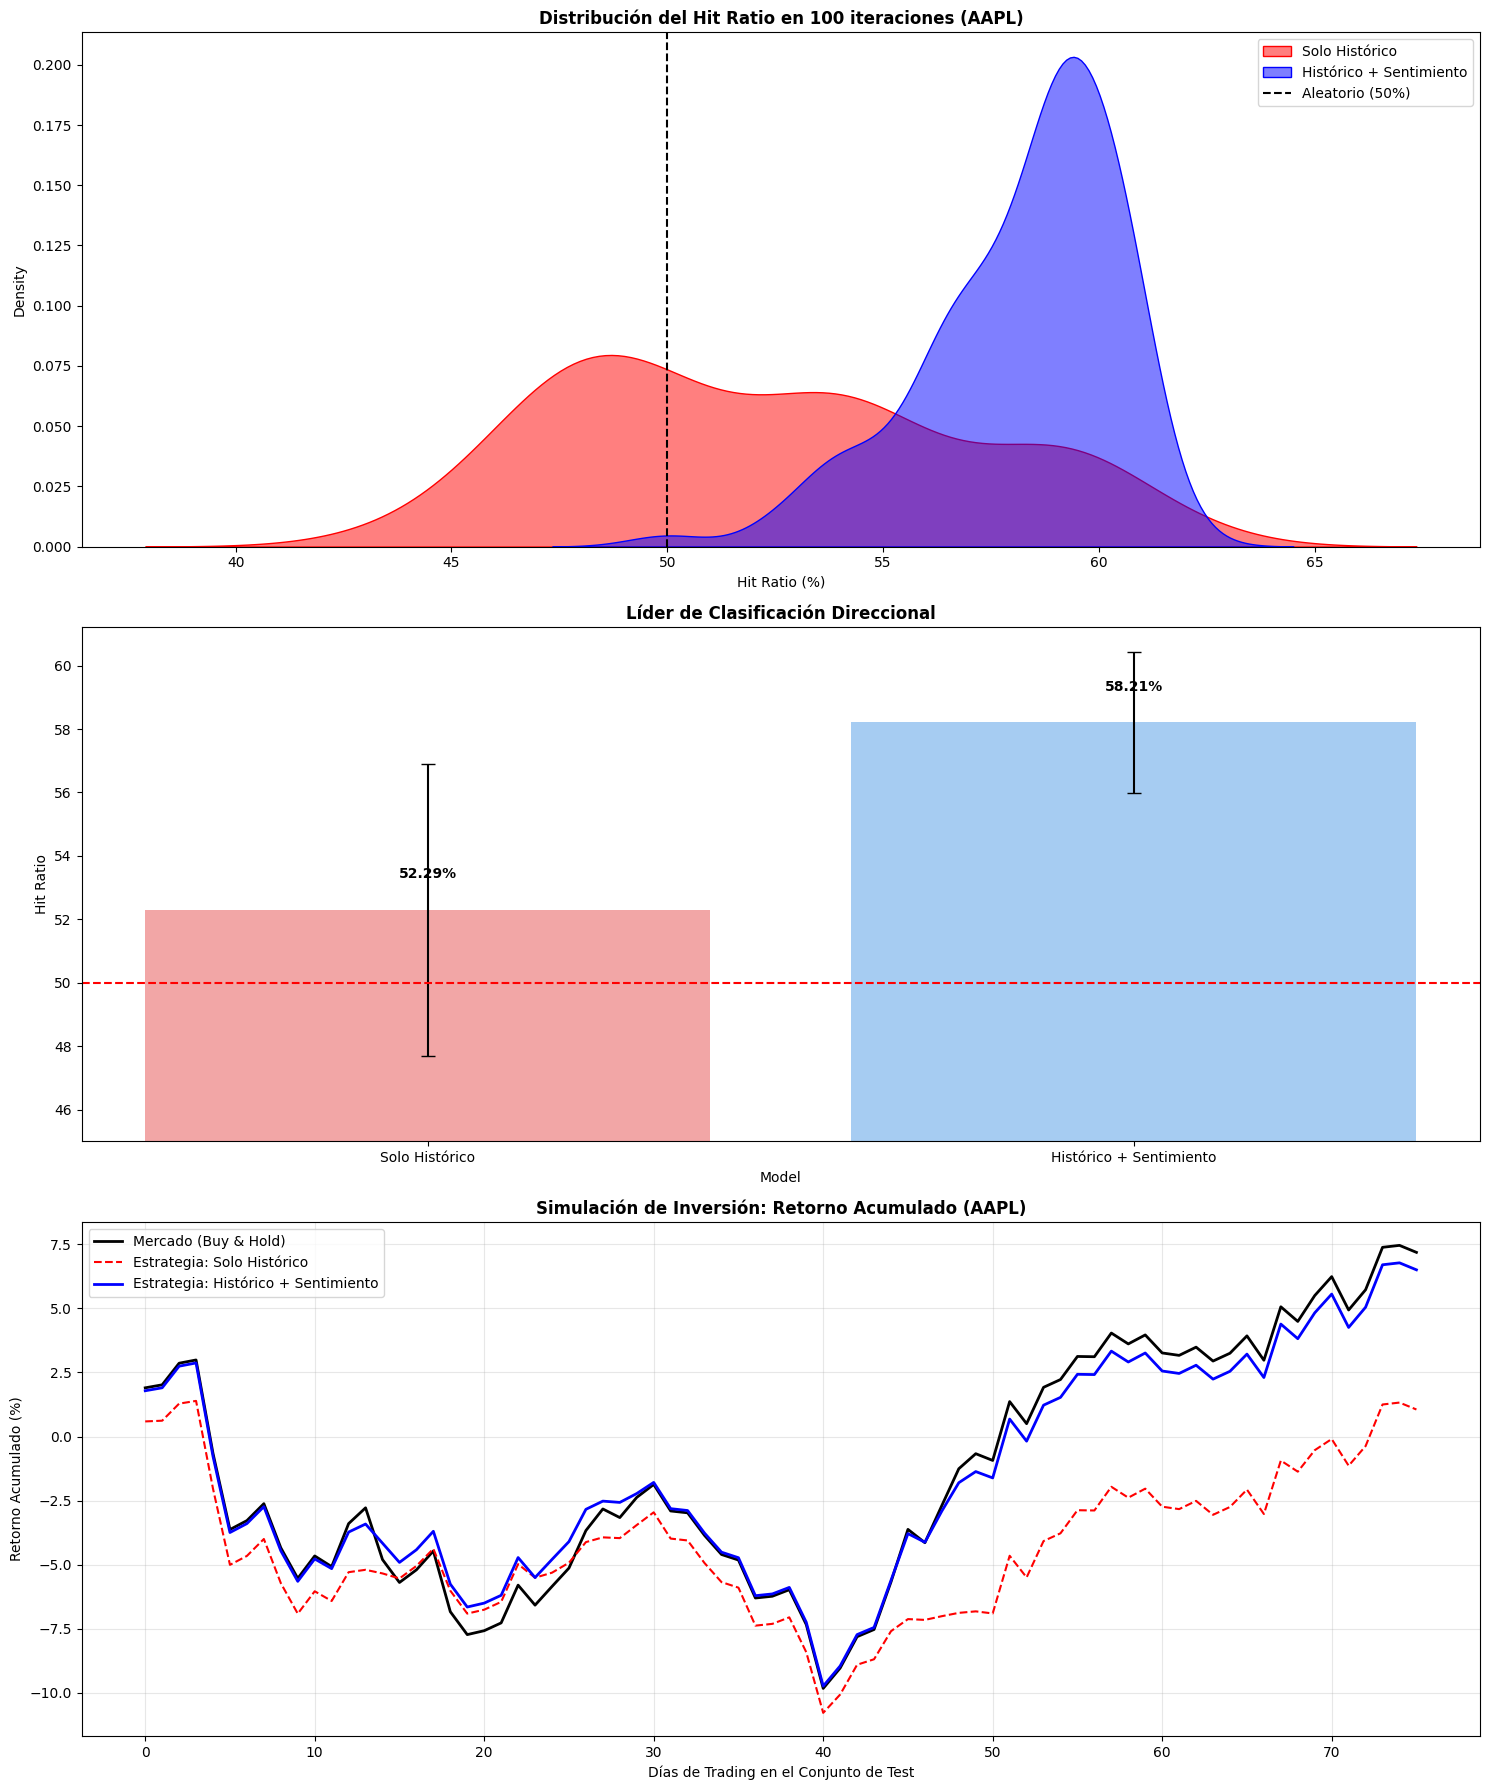

In [ ]:
experimento_diferenciacion_direccional_finn('AAPL', n_runs=100, window_size=10)